# EDA: River Water Quality

This notebook explores the dataset, fixes column names, checks missing values, and prepares a clean training table for modeling.

## Setup
Import libraries, set plotting defaults, and define the data path.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "train.csv"

## Load and clean
Read the CSV, normalize column names, coerce numeric types, and preview the table.

In [2]:
df_raw = pd.read_csv(DATA_PATH, engine="python", skipinitialspace=True)


def normalize_columns(cols):
    cleaned = []
    for col in cols:
        col = str(col).strip().lower()
        col = re.sub(r"[^0-9a-zA-Z_]+", "", col)
        cleaned.append(col)
    return cleaned

raw_cols = df_raw.columns.tolist()
clean_cols = normalize_columns(raw_cols)
rename_map = dict(zip(raw_cols, clean_cols))

print("Raw columns:")
print(raw_cols)

print("\nCleaned columns:")
print(clean_cols)

df = df_raw.rename(columns=rename_map)

# Drop empty or unnamed columns created by trailing commas
bad_cols = [c for c in df.columns if c == "" or c.lower().startswith("unnamed")]
if bad_cols:
    df = df.drop(columns=bad_cols)

# Coerce all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nShape:", df.shape)
df.head()

Raw columns:
['Id ', 'target', 'O2_1               ', 'O2_2               ', 'O2_3  ', 'O2_4  ', 'O2_5  ', 'O2_6  ', 'O2_7  ', 'NH4_1              ', 'NH4_2              ', 'NH4_3             ', 'NH4_4 ', 'NH4_5              ', 'NH4_6             ', 'NH4_7               ', 'NO2_1               ', 'NO2_2               ', 'NO2_3              ', 'NO2_4 ', 'NO2_5                ', 'NO2_6               ', 'NO2_7               ', 'NO3_1              ', 'NO3_2              ', 'NO3_3             ', 'NO3_4  ', 'NO3_5 ', 'NO3_6  ', 'NO3_7 ', 'BOD5_1             ', 'BOD5_2             ', 'BOD5_3', 'BOD5_4            ', 'BOD5_5            ', 'BOD5_6', 'BOD5_7']

Cleaned columns:
['id', 'target', 'o2_1', 'o2_2', 'o2_3', 'o2_4', 'o2_5', 'o2_6', 'o2_7', 'nh4_1', 'nh4_2', 'nh4_3', 'nh4_4', 'nh4_5', 'nh4_6', 'nh4_7', 'no2_1', 'no2_2', 'no2_3', 'no2_4', 'no2_5', 'no2_6', 'no2_7', 'no3_1', 'no3_2', 'no3_3', 'no3_4', 'no3_5', 'no3_6', 'no3_7', 'bod5_1', 'bod5_2', 'bod5_3', 'bod5_4', 'bod5_5', 'bod5_6', 'b

,id,target,o2_1,o2_2,o2_3,o2_4,o2_5,o2_6,o2_7,nh4_1,...,no3_5,no3_6,no3_7,bod5_1,bod5_2,bod5_3,bod5_4,bod5_5,bod5_6,bod5_7
0,0,12.58,9.875,9.20,NaN,NaN,NaN,NaN,NaN,0.690,...,NaN,NaN,NaN,4.80,5.850,NaN,NaN,NaN,NaN,NaN
1,3,9.37,10.300,10.75,NaN,NaN,NaN,NaN,NaN,0.710,...,NaN,NaN,NaN,5.88,6.835,NaN,NaN,NaN,NaN,NaN
2,4,8.35,8.290,7.90,NaN,NaN,NaN,NaN,NaN,2.210,...,NaN,NaN,NaN,3.20,2.700,NaN,NaN,NaN,NaN,NaN
3,5,9.57,8.820,6.80,NaN,NaN,NaN,NaN,NaN,0.595,...,NaN,NaN,NaN,7.70,7.055,NaN,NaN,NaN,NaN,NaN
4,6,6.00,6.000,6.50,NaN,NaN,NaN,NaN,NaN,0.600,...,NaN,NaN,NaN,5.50,5.300,NaN,NaN,NaN,NaN,NaN


## Data quality checks
Summarize missing values, duplicates, and basic statistics.

In [3]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_counts = df.isna().sum().sort_values(ascending=False)

print("Missing ratio (top 15):")
print(missing_ratio.head(15))

print("\nMissing counts (top 15):")
print(missing_counts.head(15))

print("\nDuplicate rows:", df.duplicated().sum())

df.describe().T

Missing ratio (top 15):
no2_4     0.789116
no3_4     0.789116
nh4_4     0.789116
o2_4      0.789116
bod5_4    0.789116
bod5_3    0.782313
no3_3     0.782313
nh4_3     0.782313
no2_3     0.782313
o2_3      0.782313
no2_5     0.775510
o2_5      0.775510
nh4_5     0.775510
no3_5     0.775510
bod5_5    0.775510
dtype: float64

Missing counts (top 15):
no2_4     116
no3_4     116
nh4_4     116
o2_4      116
bod5_4    116
bod5_3    115
no3_3     115
nh4_3     115
no2_3     115
o2_3      115
no2_5     114
o2_5      114
nh4_5     114
no3_5     114
bod5_5    114
dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
id,147.0,101.401361,64.836640,0.000,41.500000,102.000000,158.50000,214.000
target,147.0,9.211497,2.886614,1.900,7.375000,8.800000,10.85000,19.100
o2_1,145.0,9.168506,4.188197,2.200,7.050000,8.700000,10.60000,46.950
o2_2,145.0,9.148126,3.746898,2.200,7.200000,8.566667,10.50000,40.900
o2_3,32.0,10.002813,2.667096,4.660,8.100000,9.522500,11.61125,15.900
o2_4,31.0,8.483226,2.527239,4.900,6.865000,7.800000,9.23250,15.400
o2_5,33.0,6.095152,3.279915,0.000,3.290000,5.800000,9.50000,11.800
o2_6,37.0,9.396892,2.848153,0.000,8.800000,9.805000,10.44000,13.700
o2_7,37.0,7.598243,3.409060,0.000,6.170000,7.150000,8.70000,15.900
nh4_1,145.0,0.588168,0.462262,0.040,0.230000,0.425000,0.80000,2.400


## Distributions and correlations
Plot the target distribution, missingness bar chart, and correlation heatmap.

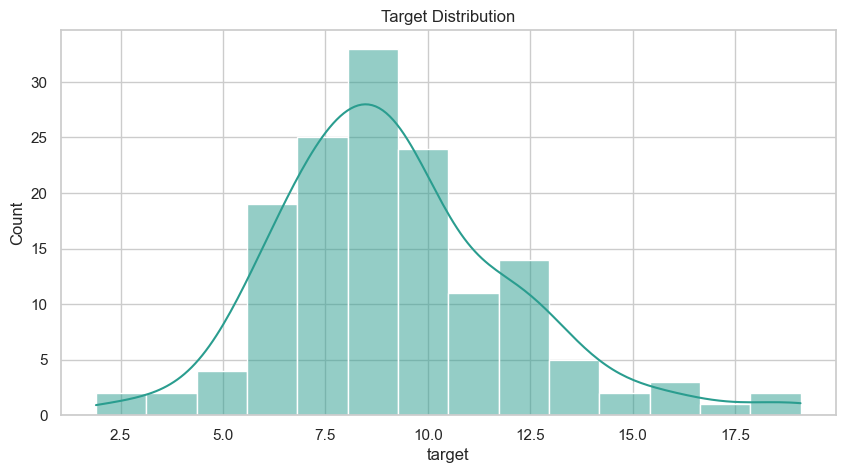

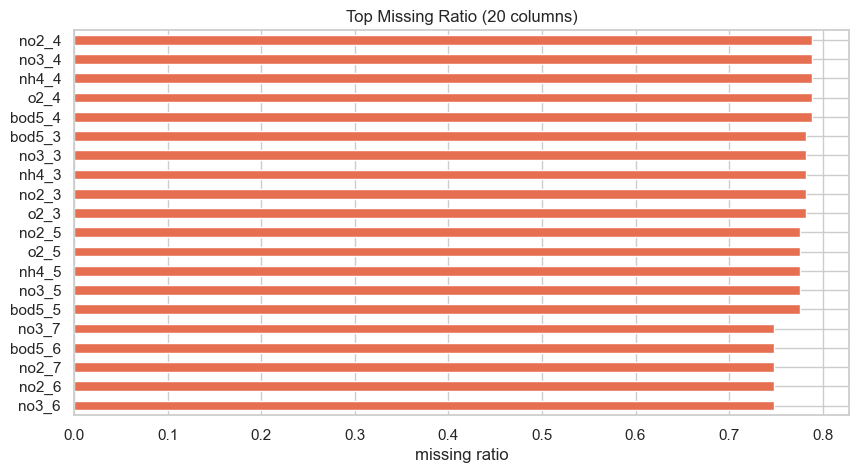

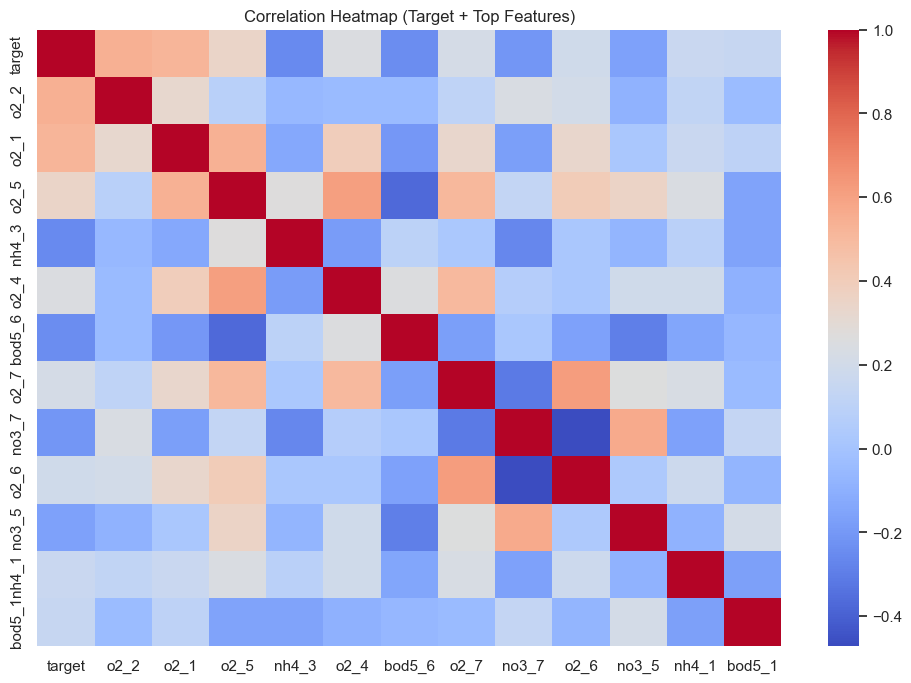

In [4]:
fig, ax = plt.subplots()
sns.histplot(df["target"], kde=True, ax=ax, color="#2a9d8f")
ax.set_title("Target Distribution")
ax.set_xlabel("target")
plt.show()

fig, ax = plt.subplots()
missing_ratio.head(20).iloc[::-1].plot(kind="barh", ax=ax, color="#e76f51")
ax.set_title("Top Missing Ratio (20 columns)")
ax.set_xlabel("missing ratio")
plt.show()

corr = df.corr(numeric_only=True)
if "target" in corr.columns:
    top_features = (
        corr["target"].drop("target").abs().sort_values(ascending=False).head(12).index
    )
    heat_cols = ["target"] + list(top_features)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(corr.loc[heat_cols, heat_cols], annot=False, cmap="coolwarm", ax=ax)
    ax.set_title("Correlation Heatmap (Target + Top Features)")
    plt.show()

## Feature relationships
Scatter plots for the top correlated features vs the target.

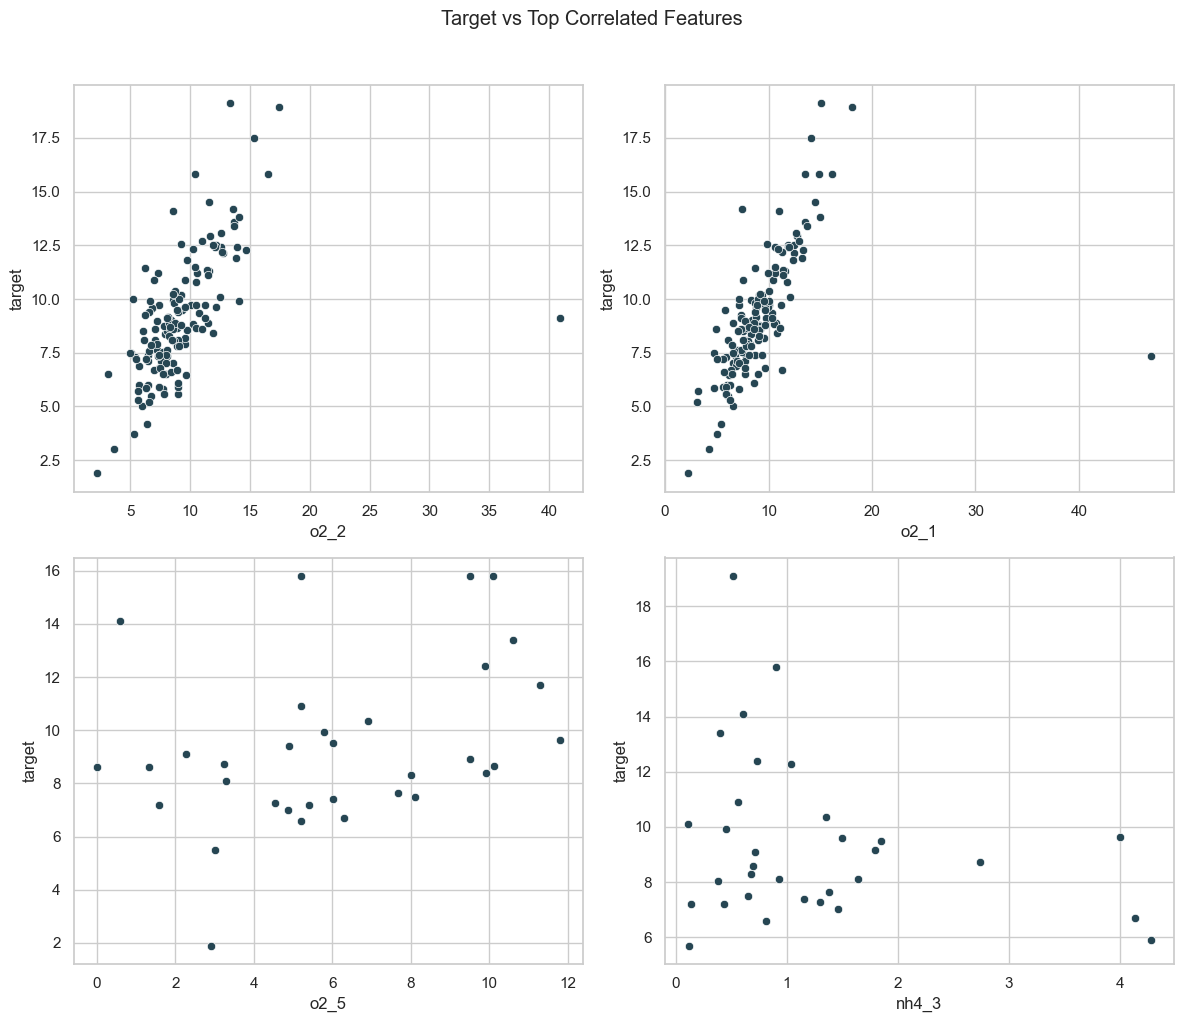

In [5]:
if "target" in corr.columns:
    top4 = (
        corr["target"].drop("target").abs().sort_values(ascending=False).head(4).index
    )
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    for ax, col in zip(axes, top4):
        sns.scatterplot(x=df[col], y=df["target"], ax=ax, color="#264653")
        ax.set_xlabel(col)
        ax.set_ylabel("target")
    fig.suptitle("Target vs Top Correlated Features", y=1.02)
    plt.tight_layout()
    plt.show()

## Prepare training data
Drop id, remove high-missing columns, impute with median, and save clean CSV.

In [6]:
from sklearn.impute import SimpleImputer

work_df = df.copy()

# Drop identifier column if present
if "id" in work_df.columns:
    work_df = work_df.drop(columns=["id"])

# Drop columns with too much missing data
missing_threshold = 0.60
cols_to_drop = missing_ratio[missing_ratio > missing_threshold].index.tolist()
if cols_to_drop:
    work_df = work_df.drop(columns=cols_to_drop)

# Separate target
if "target" not in work_df.columns:
    raise ValueError("Target column not found after cleaning.")

y = work_df["target"]
X = work_df.drop(columns=["target"])

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

clean_df = pd.concat([y.reset_index(drop=True), X_imputed], axis=1)

print("Before cleaning:", df.shape)
print("After cleaning:", clean_df.shape)

clean_df.to_csv("train_clean.csv", index=False)
clean_df.head()

Before cleaning: (147, 37)
After cleaning: (147, 11)


,target,o2_1,o2_2,nh4_1,nh4_2,no2_1,no2_2,no3_1,no3_2,bod5_1,bod5_2
0,12.58,9.875,9.20,0.690,1.040,0.0940,0.0990,1.58,1.825,4.80,5.850
1,9.37,10.300,10.75,0.710,0.725,0.0585,0.0515,1.21,0.905,5.88,6.835
2,8.35,8.290,7.90,2.210,2.210,0.1000,0.1100,1.34,1.250,3.20,2.700
3,9.57,8.820,6.80,0.595,0.675,0.0460,0.0535,0.59,0.790,7.70,7.055
4,6.00,6.000,6.50,0.600,0.900,0.1800,0.3400,1.36,1.820,5.50,5.300


## Placeholder
No action in the cell below.

## Placeholder
No action in the cell below.

## Placeholder
No action in the cell below.

## Placeholder
No action in the cell below.